In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
df = pd.read_csv("../data/processed/HDFCBANK_features.csv")

In [3]:
data = df[["Close"]]

In [4]:
data.head()

,Close
0,475.805664
1,498.401001
2,465.649414
3,454.281891
4,408.532318


In [5]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [6]:
scaled_data[:5]

array([[0.18496366],
       [0.22033731],
       [0.16906376],
       [0.15126758],
       [0.07964531]])

In [7]:
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

In [8]:
X = np.array(X)
y = np.array(y)

In [9]:
print(X.shape)
print(y.shape)

(1502, 60)
(1502,)


In [10]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [11]:
print(X.shape)

(1502, 60, 1)


In [12]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [13]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

c:\Users\iamga\Live_Stock_Analysis_Prediction\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - loss: 0.0282 - val_loss: 0.0175
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0044 - val_loss: 0.0056
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0038 - val_loss: 0.0047
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0037 - val_loss: 0.0015
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0033 - val_loss: 0.0014
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0030 - val_loss: 0.0013
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0029 - val_loss: 0.0044
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 0.0032 - val_loss: 0.0055
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step

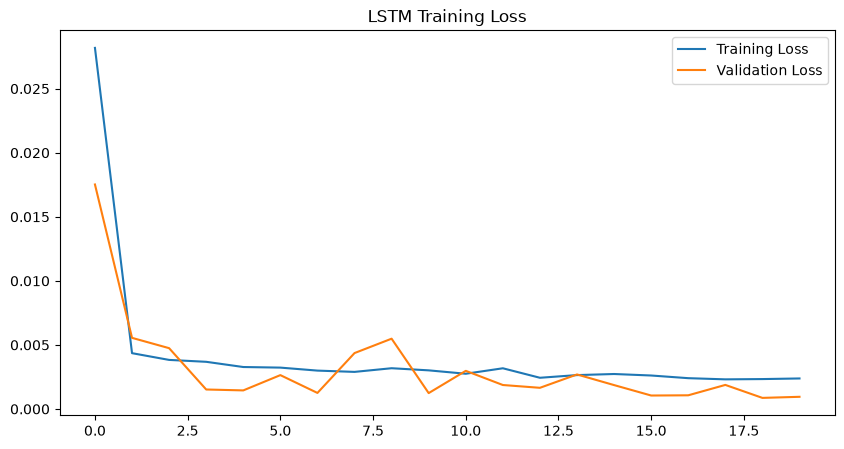

In [17]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.legend()

plt.title("LSTM Training Loss")

plt.show()

In [18]:
predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step


In [19]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test.reshape(-1,1))

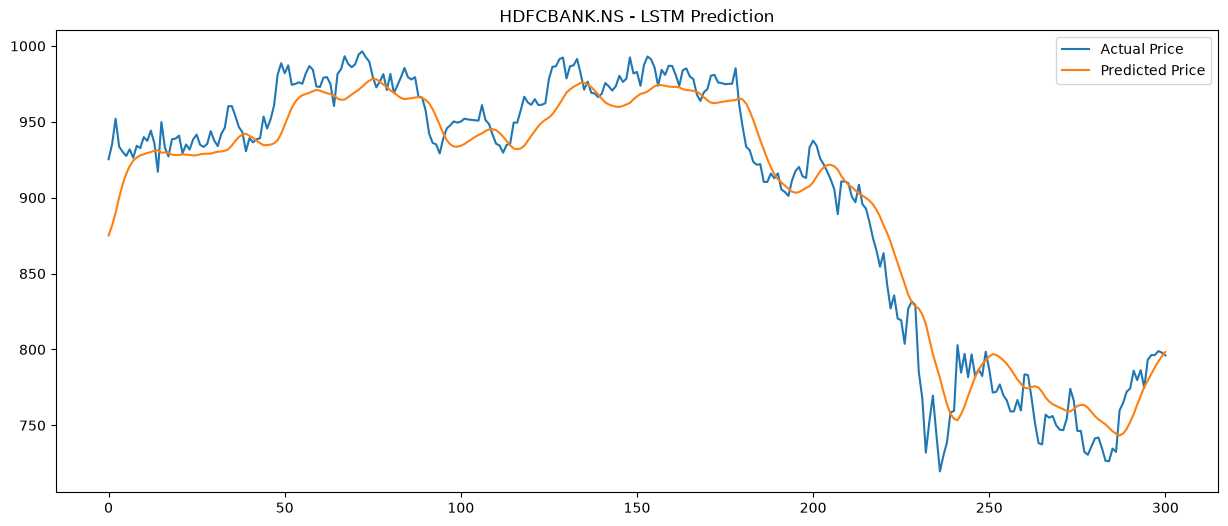

In [20]:
plt.figure(figsize=(15,6))

plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("HDFCBANK.NS - LSTM Prediction")

plt.legend()

plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 15.422876503776477
RMSE : 19.69005850425798


In [22]:
model.save("../models/lstm_model.keras")

In [23]:
from tensorflow.keras.models import load_model

model = load_model("../models/lstm_model.keras")